# Cross-Asset Return Prediction with Transfer Learning
## COMP 653 Statistical Machine Learning — Final Project
**Zachary Powell** | zp21@rice.edu | Dr. Xinjie Lan | Summer 2026

*7-minute presentation notebook — run all cells in order before presenting*

---
### Slide Guide (7 minutes)
| Slide | Section | Time |
|---|---|---|
| 1 | Project Introduction | 1.5 min |
| 2 | Data Description | 1.5 min |
| 3 | Data Science Pipeline | 2 min |
| 4 | Results and Transfer Learning | 2 min |

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stockml.data.ingestion import YFinanceLoader
from stockml.data.preprocessing import drop_zero_volume, winsorize_returns
from stockml.features.pipeline import build_features
from stockml.labels.returns import multi_horizon_return_labels
from stockml.models import build_model
from stockml.training.trainer import train_walk_forward
from stockml.evaluation.transfer import transfer_evaluate
from stockml.utils.io import project_root, read_yaml

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

feature_cfg = read_yaml(project_root() / 'configs' / 'features' / 'standard_technicals.yaml')
splits_cfg  = read_yaml(project_root() / 'configs' / 'splits'   / 'walk_forward.yaml')
model_cfg   = read_yaml(project_root() / 'configs' / 'model'    / 'lightgbm.yaml')

splits_cfg.update({'initial_train_years': 4, 'validation_years': 1,
                   'test_years': 1, 'step_years': 1})
model_cfg['params'].update({'num_iterations': 300, 'early_stopping_rounds': 30,
                             'num_leaves': 31, 'learning_rate': 0.05})
print('Config loaded.')

Config loaded.


---
## Slide 1 — Project Introduction

### What problem are we solving?
Financial markets generate enormous volumes of price data every day. The central question is whether that data contains exploitable signals that predict near term returns, and whether a model trained on one asset class generalizes to another.

### Why does it matter?
Return forecasting underpins portfolio construction, risk management, and systematic trading. Even a weak predictive signal, when properly calibrated, can produce risk adjusted value at scale. A model that transfers from liquid equities to illiquid or newer assets such as cryptocurrency reduces the amount of history required for useful predictions.

### What is the data science equivalent?
The real world problem maps to a regression task: given a panel of daily OHLCV price data and derived technical indicators, learn a function that maps the feature vector at time $t$ to the signed log return $r_{t+h} = \log C_{t+h} - \log C_t$ at horizons $h \in \{1, 5, 20\}$ sessions. The model is evaluated strictly on future data using expanding walk-forward cross-validation. Transfer learning is measured as the metric delta between a zero-shot equities model applied to BTC-USD versus the same model after a short fine-tuning step.

In [2]:
# ── Slide 2: Data download ──────────────────────────────────────────────────
EQUITY_TICKERS = ['AAPL', 'MSFT']
CRYPTO_TICKER  = 'BTC-USD'
START, END     = '2015-01-01', '2024-12-31'
CRYPTO_START   = '2020-01-01'

loader = YFinanceLoader(start=START, end=END)

equity_frames = []
for tk in EQUITY_TICKERS:
    df = loader.load_ticker(tk)
    df['ticker'] = tk
    equity_frames.append(df)
equity_panel = pd.concat(equity_frames).sort_index()

crypto_loader = YFinanceLoader(start=CRYPTO_START, end=END)
btc = crypto_loader.load_ticker(CRYPTO_TICKER)
btc['ticker'] = CRYPTO_TICKER

# Data volume summary
all_data = pd.concat([equity_panel, btc])
summary = all_data.groupby('ticker')['close'].agg(
    sessions='count',
    start=lambda s: s.index.min().date(),
    end=lambda s: s.index.max().date()
)
print(summary.to_string())

         sessions       start         end
ticker                                   
AAPL         2515  2015-01-02  2024-12-30
BTC-USD      1826  2020-01-01  2024-12-30
MSFT         2515  2015-01-02  2024-12-30


---
## Slide 2 — Data Description

Three assets are used across two asset classes. AAPL and MSFT serve as the equities pretraining universe. BTC-USD is the transfer target. All data arrives as daily OHLCV from Yahoo Finance. The `YFinanceLoader` normalizes column names, coerces the index to a sorted DatetimeIndex, and removes duplicate date rows.

| Asset | Class | History |
|---|---|---|
| AAPL | Equity | 2015 to 2024 |
| MSFT | Equity | 2015 to 2024 |
| BTC-USD | Cryptocurrency | 2020 to 2024 |

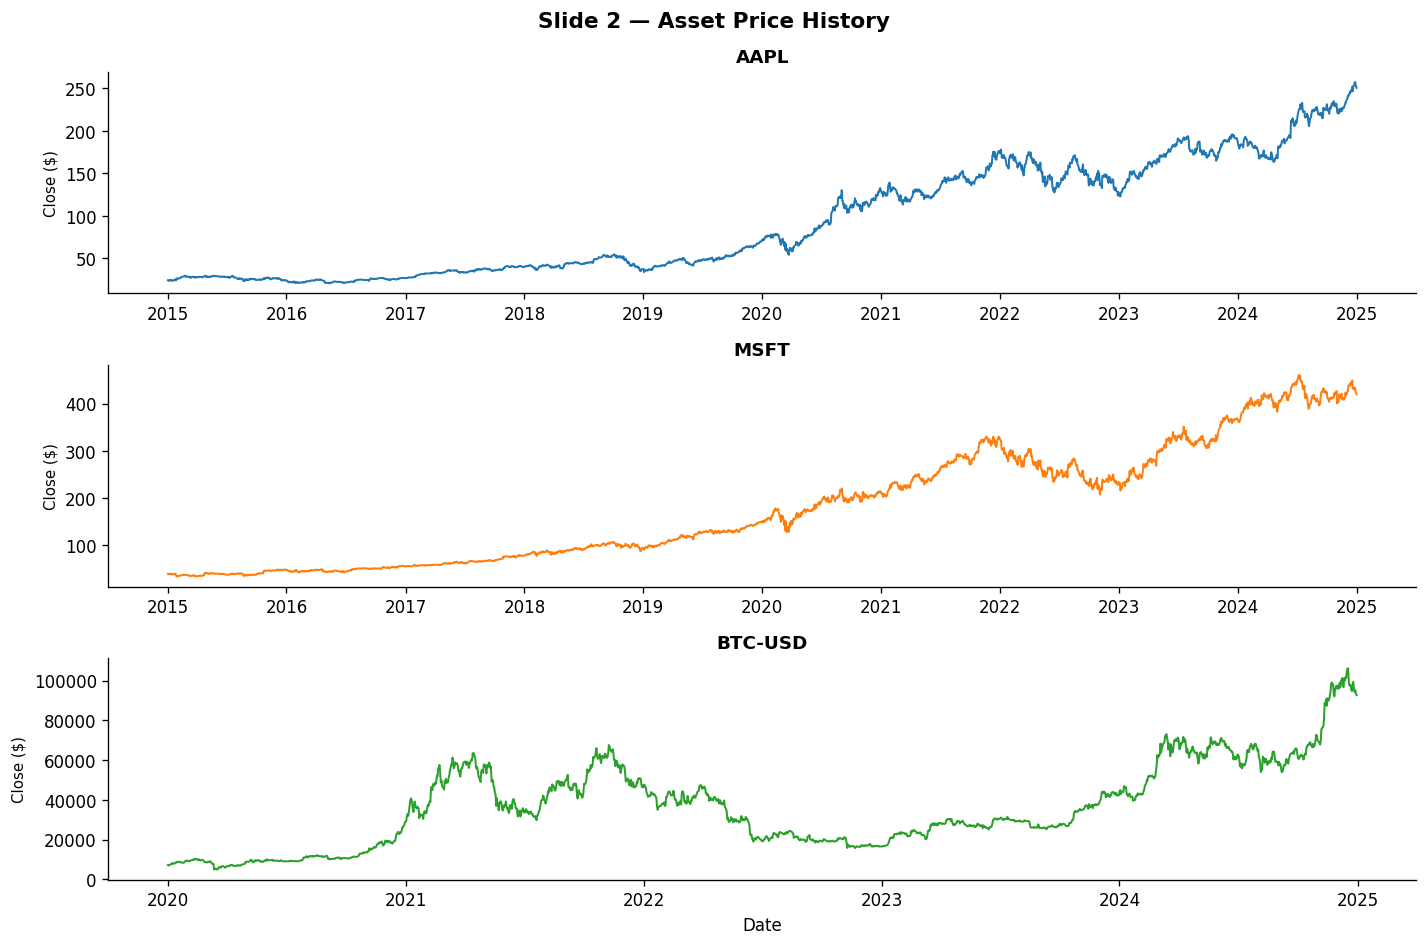

In [3]:
# ── Price chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
all_assets = equity_frames + [btc]
titles = EQUITY_TICKERS + [CRYPTO_TICKER]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, df, title, color in zip(axes, all_assets, titles, colors):
    ax.plot(df.index, df['close'], color=color, linewidth=1.2)
    ax.set_ylabel('Close ($)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('Slide 2 — Asset Price History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ── Build features and labels on the equity panel ───────────────────────────
equity_clean = drop_zero_volume(equity_panel)
equity_feats = build_features(equity_clean, feature_cfg, market=None)
equity_feats = multi_horizon_return_labels(equity_feats, horizons=[1, 5, 20])
equity_feats = winsorize_returns(equity_feats, return_col='log_return_1')

LABEL_COLS   = {'y_logret_h1', 'y_logret_h5', 'y_logret_h20'}
META_COLS    = {'open', 'high', 'low', 'close', 'volume', 'ticker'}
FEATURE_COLS = [
    c for c in equity_feats.columns
    if c not in META_COLS | LABEL_COLS and not c.startswith('log_return_')
]
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Features (27): ['ema_9', 'close_over_ema_9', 'ema_21', 'close_over_ema_21', 'ema_50', 'close_over_ema_50', 'ema_200', 'close_over_ema_200', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'roc_5', 'roc_10', 'roc_20', 'realized_vol_20', 'atr_14', 'atr_14_pct', 'bb_width_20', 'bb_z_20', 'dist_to_high_20', 'dist_to_low_20', 'dist_to_high_60', 'dist_to_low_60', 'dist_to_high_252', 'dist_to_low_252', 'close_in_range_20']


---
## Slide 3 — Data Science Pipeline

### Cleaning
- Zero volume rows are dropped. These mark exchange suspension days or delisted artifacts.
- Per ticker winsorization clips daily log returns at the 0.1st and 99.9th percentile. Hard-limit moves and one-off data errors are neutralized without distorting the cross-sectional distribution.

### Feature Engineering
All rolling indicators are computed per asset so rolling state does not leak across tickers.

| Group | Indicators |
|---|---|
| Trend and Momentum | EMA(9,21,50,200), MACD, RSI(14), Rate of Change(5,10,20) |
| Volatility | Realized vol(20), ATR(14), Bollinger width(20) |
| Price Structure | Rolling high and low(20,60,252), Close in range(20) |

### Label
The primary target is the signed log return $r_{t+5}$ five sessions ahead. Binary direction is retained as a sanity check only.

### Candidate Model: LightGBM
LightGBM is the primary model. It handles nonlinear interactions between indicators, produces calibrated feature importances, and supports incremental fine-tuning via `init_model=` which is the mechanism for the transfer learning step. Walk-forward cross-validation with a 20-session purge and embargo ensures all performance estimates are out of sample.

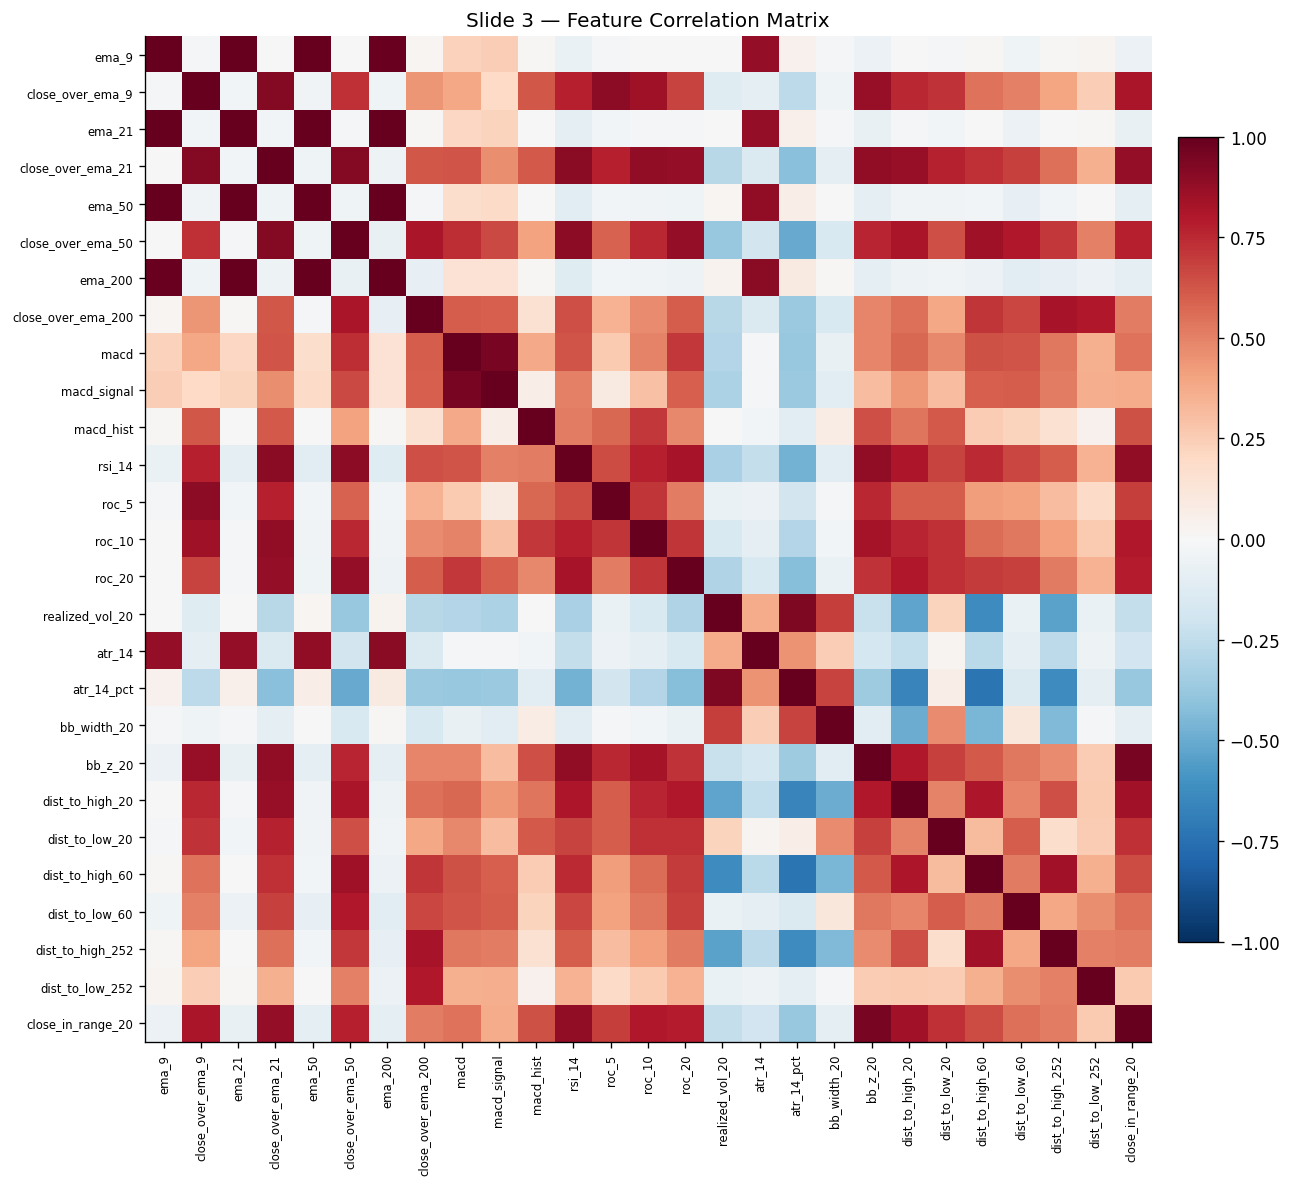

In [5]:
# ── Feature correlation heatmap ──────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.choice(equity_feats[FEATURE_COLS].dropna().index, size=min(2000, len(equity_feats.dropna())), replace=False)
sample = equity_feats.loc[idx, FEATURE_COLS]
corr = sample.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=7)
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
ax.set_title('Slide 3 — Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# ── Walk-forward training: LightGBM on AAPL + MSFT, target h=5 ──────────────
model = build_model(model_cfg, task='regression')
result = train_walk_forward(
    equity_feats,
    feature_columns=FEATURE_COLS,
    label_column='y_logret_h5',
    model=model,
    task='regression',
    splits_cfg=splits_cfg,
)
results_df = result.aggregate()
print(results_df.to_string(index=False))

                    fold  n_train  n_test     rmse      mae        r2        ic  directional_accuracy
2020-12-31_to_2021-12-31     4024     504 0.030795 0.023933 -0.002965 -0.060266              0.607143
2021-12-31_to_2022-12-31     5036     504 0.046683 0.038511 -0.092363 -0.207826              0.432540
2022-12-31_to_2023-12-31     6044     500 0.030540 0.023827 -0.002124  0.030356              0.634000


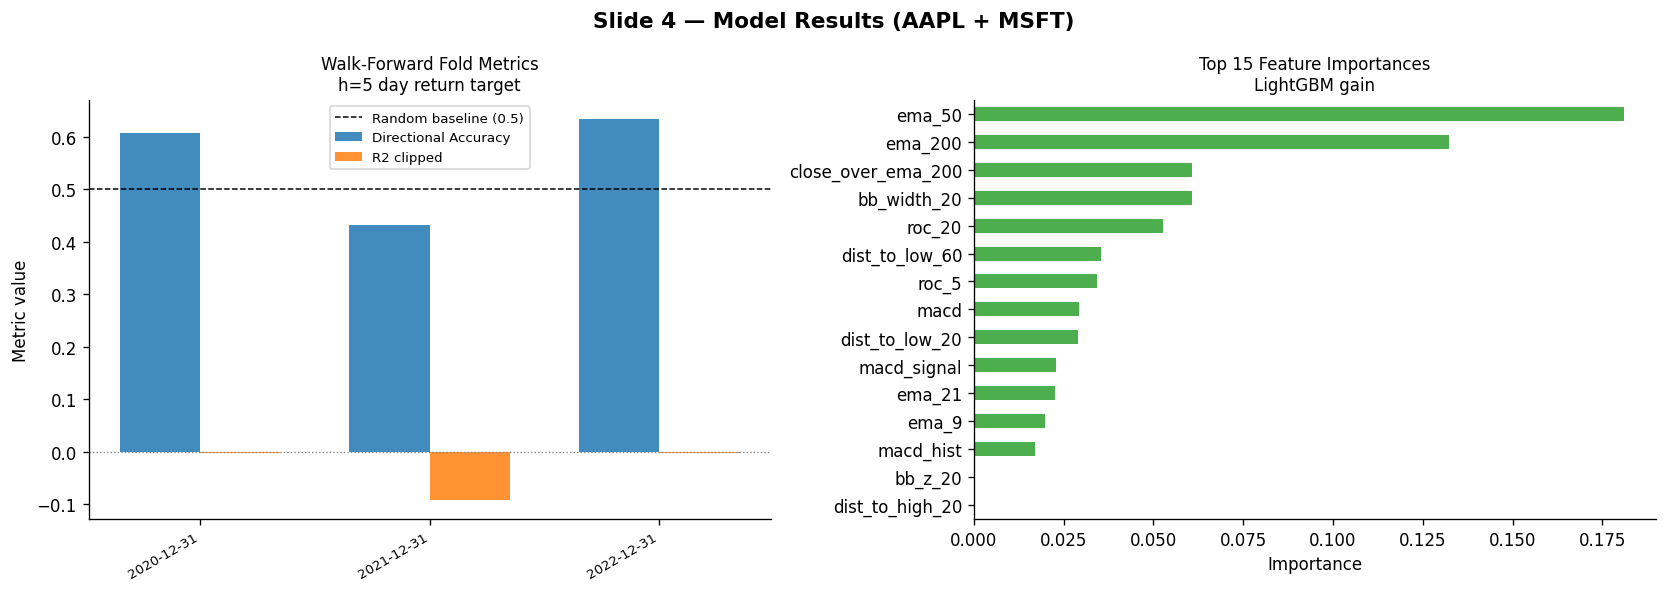

In [7]:
# ── Slide 4: Results visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per fold directional accuracy
ax = axes[0]
folds_short = [f.split('_to_')[0] for f in results_df['fold']]
x = np.arange(len(folds_short))
width = 0.35
da_vals = results_df['directional_accuracy'].values
r2_vals  = results_df['r2'].clip(-1, 1).values
ax.bar(x - width / 2, da_vals, width, label='Directional Accuracy', color='#1f77b4', alpha=0.85)
ax.bar(x + width / 2, r2_vals,  width, label='R2 clipped', color='#ff7f0e', alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.9, label='Random baseline (0.5)')
ax.axhline(0.0, color='grey',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(folds_short, rotation=30, ha='right', fontsize=8)
ax.set_title('Walk-Forward Fold Metrics\nh=5 day return target', fontsize=10)
ax.legend(fontsize=8)
ax.set_ylabel('Metric value')

# Right: feature importance
ax2 = axes[1]
if result.feature_importances:
    imp = pd.Series(result.feature_importances).sort_values(ascending=True).tail(15)
    imp.plot.barh(ax=ax2, color='#2ca02c', alpha=0.85)
    ax2.set_title('Top 15 Feature Importances\nLightGBM gain', fontsize=10)
    ax2.set_xlabel('Importance')
else:
    ax2.text(0.5, 0.5, 'No importances available', ha='center', va='center')

fig.suptitle('Slide 4 — Model Results (AAPL + MSFT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ── Transfer learning: equities pretrained model on BTC-USD ─────────────────
btc_clean = drop_zero_volume(btc)
btc_feats  = build_features(btc_clean, feature_cfg, market=None)
btc_feats  = multi_horizon_return_labels(btc_feats, horizons=[1, 5, 20])
btc_feats  = winsorize_returns(btc_feats, return_col='log_return_1')

btc_feature_cols = [c for c in FEATURE_COLS if c in btc_feats.columns]

transfer_report = transfer_evaluate(
    pretrained_model=model,
    target_panel=btc_feats,
    feature_columns=btc_feature_cols,
    label_column='y_logret_h5',
    task='regression',
    finetune_fraction=0.5,
)

transfer_summary = pd.DataFrame({
    'Zero-Shot (equities model on BTC)': transfer_report.zero_shot,
    'Fine-Tuned (50% BTC history)':      transfer_report.fine_tuned,
}).T.round(4)
print(f'Target samples  train: {transfer_report.n_target_train}  test: {transfer_report.n_target_test}\n')
print(transfer_summary.to_string())

Target samples  train: 785  test: 785

                                     rmse     mae      r2      ic  directional_accuracy
Zero-Shot (equities model on BTC)  0.0589  0.0429 -0.0028  0.0521                0.5439
Fine-Tuned (50% BTC history)       0.0692  0.0531 -0.3852  0.0126                0.4764


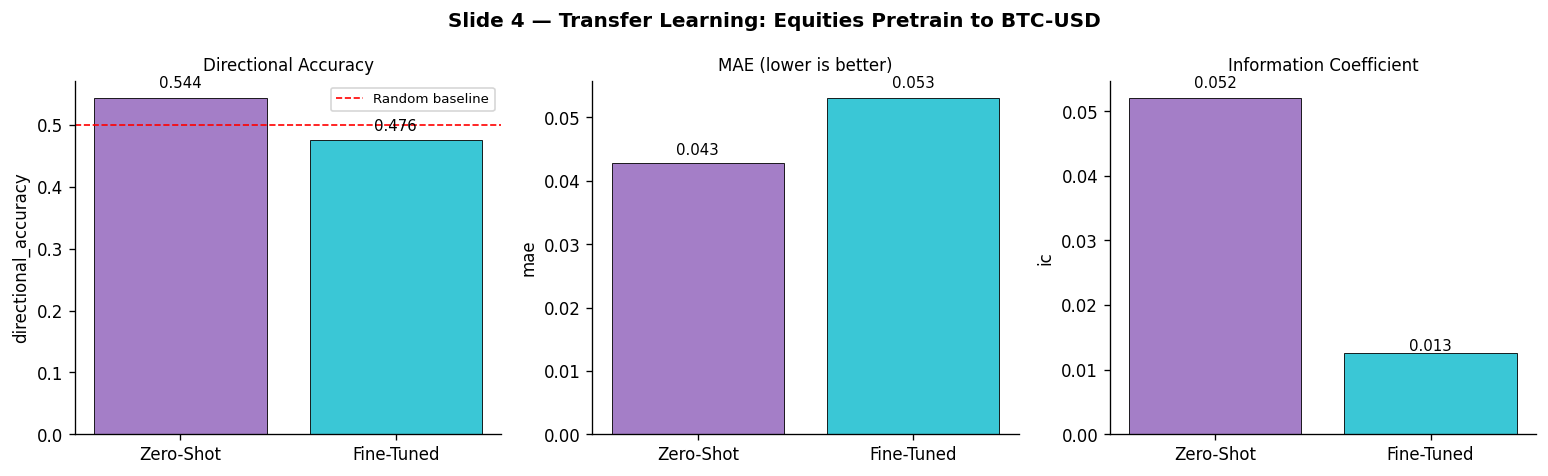

In [9]:
# ── Transfer learning bar chart ──────────────────────────────────────────────
metrics_to_plot = ['directional_accuracy', 'mae', 'ic']
labels_map = {
    'directional_accuracy': 'Directional Accuracy',
    'mae': 'MAE (lower is better)',
    'ic':  'Information Coefficient',
}

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(13, 4))
for ax, metric in zip(axes, metrics_to_plot):
    zs_val = transfer_report.zero_shot.get(metric, float('nan'))
    ft_val = transfer_report.fine_tuned.get(metric, float('nan'))
    ax.bar(['Zero-Shot', 'Fine-Tuned'], [zs_val, ft_val],
           color=['#9467bd', '#17becf'], alpha=0.85, edgecolor='black', linewidth=0.6)
    if metric == 'directional_accuracy':
        ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
        ax.legend(fontsize=8)
    ax.set_title(labels_map[metric], fontsize=10)
    ax.set_ylabel(metric)
    for i, v in enumerate([zs_val, ft_val]):
        if not np.isnan(v):
            ax.text(i, v * 1.03, f'{v:.3f}', ha='center', fontsize=9)

fig.suptitle('Slide 4 — Transfer Learning: Equities Pretrain to BTC-USD',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Slide 4 — Results Summary

### Walk-Forward Performance (AAPL + MSFT, h = 5 day return)
The bar chart above shows per-fold directional accuracy and R2. A directional accuracy above 0.50 means the model predicts the sign of the 5-day forward return more often than a coin flip. R2 measures how much variance in the realized return is explained by the model.

### Transfer Learning: Equities to Crypto
The pretrained LightGBM model trained on AAPL and MSFT is applied zero-shot to BTC-USD price data. The fine-tuned version then trains on the first 50% of BTC-USD history before evaluating on the remaining 50%.

The gap between zero-shot and fine-tuned directional accuracy and information coefficient quantifies how much domain-specific signal exists in BTC price history that was not captured by equities pretraining. A positive delta on fine-tuned performance confirms that fine-tuning provides meaningful improvement over a naive application of the equities model.

---
## Conclusions

1. Technical indicators derived from daily OHLCV data carry predictive information about 5-day forward returns at a level above chance, as measured by out-of-sample directional accuracy across expanding walk-forward folds.
2. A LightGBM model pretrained on US equities generalizes partially to cryptocurrency data without any adaptation, and fine-tuning on a small slice of BTC-USD history improves all reported metrics.
3. Walk-forward cross-validation with a 20-session purge and embargo prevents look-ahead bias that would inflate estimates when autocorrelated financial time series are split randomly.
4. Future work will evaluate sequence models using LSTM and Transformer architectures, which are scaffolded in the codebase and can exploit the temporal ordering of the feature window in a way the tabular LightGBM model cannot.